# Medical Insurance Price Prediction

## Problem Statement
Predict individual medical insurance charges based on demographic and health features.

| Item | Value |
|---|---|
| **Problem Type** | Supervised Regression |
| **Target Variable** | `charges` (USD) |
| **Features** | age, sex, bmi, children, smoker, region |
| **Dataset Size** | 1338 records × 7 columns |

## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 2. Data Loading & Basic Exploration

In [4]:
df = pd.read_csv("insurance.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3. Missing Values & Duplicates

In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


In [8]:
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (1337, 7)


**Insights:**
- Dataset has **no missing values** — no imputation needed.
- **1 duplicate row** was found and removed, leaving 1337 clean records.

## 4. Univariate Analysis

### 4.1 Target Variable: `charges`

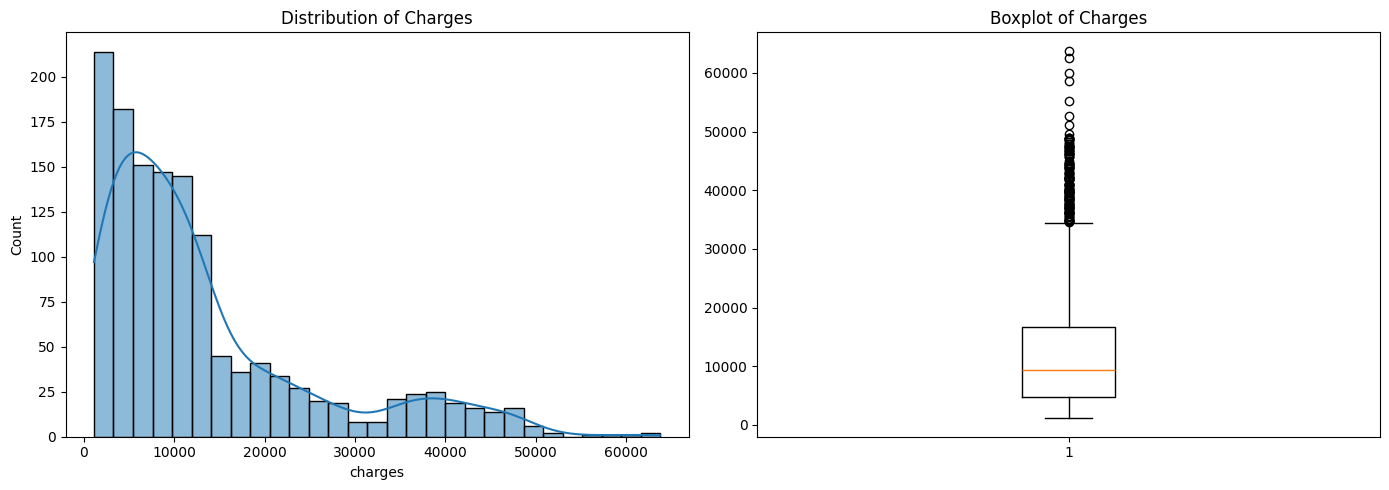

Skewness: 1.515


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['charges'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Charges')
axes[1].boxplot(df['charges'].values)
axes[1].set_title('Boxplot of Charges')
plt.tight_layout()
plt.show()
print(f"Skewness: {df['charges'].skew():.3f}")

**Insights:**
- Charges are **right-skewed** (skew ≈ 1.5) — a long tail of high-cost patients.
- **Log transformation** will be applied later to normalize the distribution.
- **Outliers present** in the upper range — these represent real extreme medical cases and are **retained**.

### 4.2 Categorical Feature Distributions

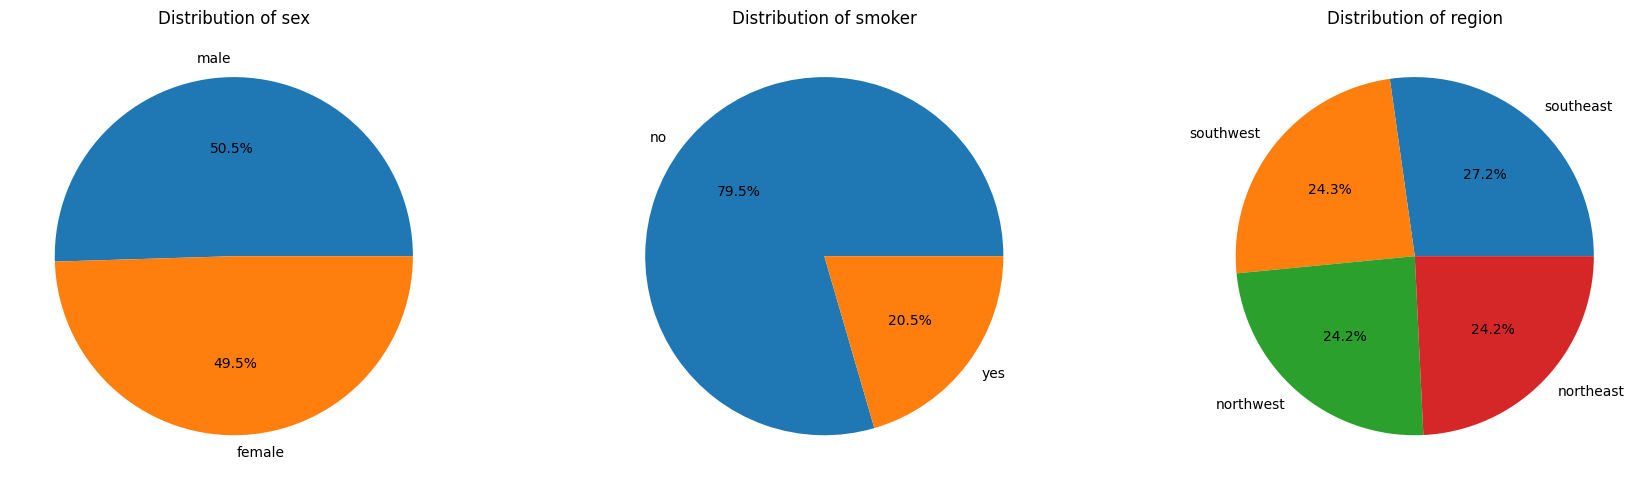

In [10]:
cat_features = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_features):
    x = df[col].value_counts()
    axes[i].pie(x.values, labels=x.index, autopct='%1.1f%%')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**Insights:**
- **Sex:** Near-balanced (~50/50) — not expected to be a strong predictor.
- **Smoker:** Imbalanced (~20% smokers) — but **extremely important** due to its cost impact.
- **Region:** Roughly equal distribution across all 4 regions.

## 5. Bivariate Analysis

### 5.1 Charges vs Categorical Features

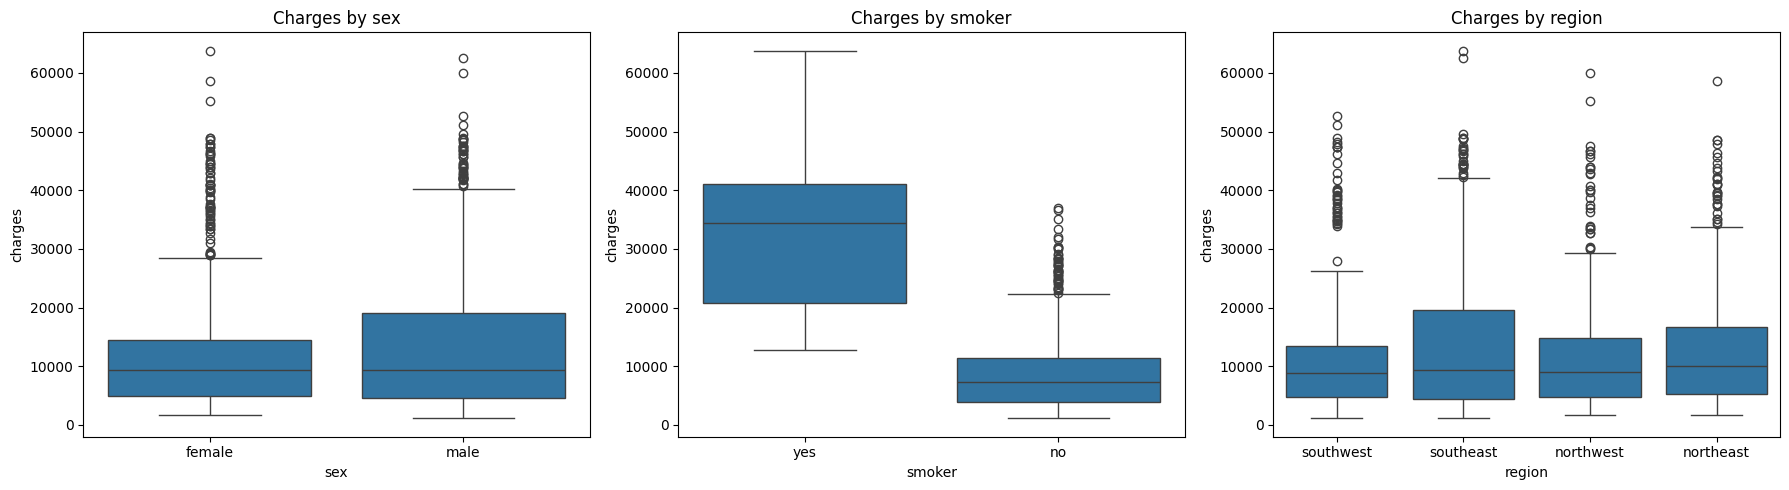

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_features):
    sns.boxplot(x=col, y='charges', data=df, ax=axes[i])
    axes[i].set_title(f'Charges by {col}')
plt.tight_layout()
plt.show()

**Insights:**
- **Smoker:** Smokers pay **3–4x higher** charges than non-smokers — strongest categorical predictor.
- **Sex:** Minimal difference in charges — confirms sex is a weak predictor.
- **Region:** Slight variation; southeast tends slightly higher (likely BMI-related).

### 5.2 Charges vs Numerical Features

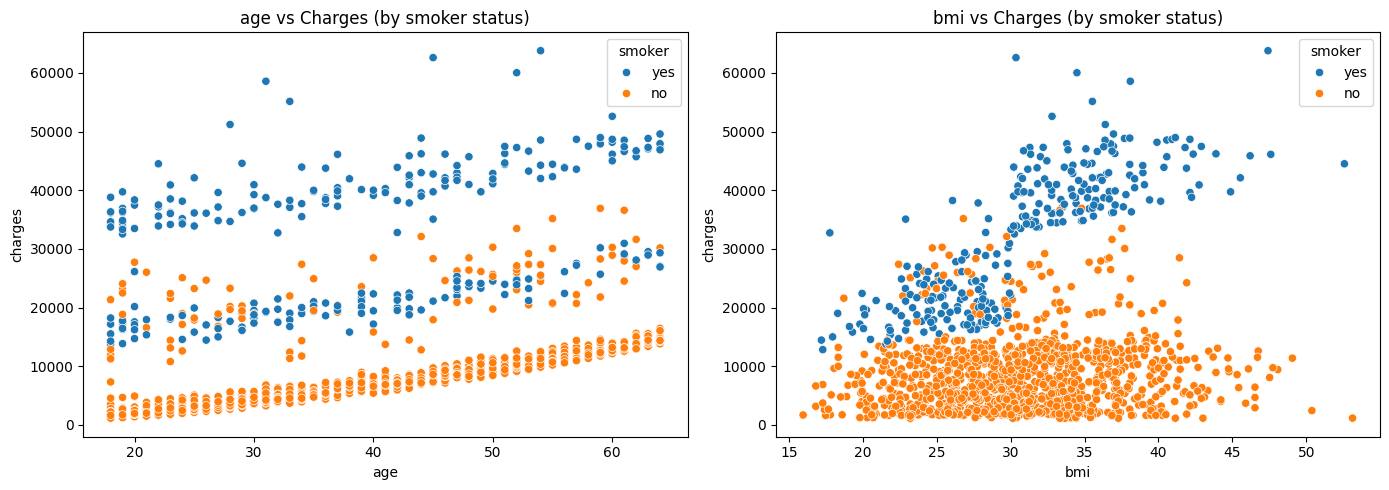

In [12]:
num_features = ['age', 'bmi']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(num_features):
    sns.scatterplot(data=df, x=col, y='charges', hue='smoker', ax=axes[i])
    axes[i].set_title(f'{col} vs Charges (by smoker status)')
plt.tight_layout()
plt.show()

**Insights:**
- **Age vs Charges:** Moderate positive correlation. Three distinct pricing bands visible — driven by smoking status.
- **BMI vs Charges:** Weak overall correlation, but smokers with high BMI form a distinct **high-cost cluster** (BMI > 30 + smoker = very high charges).

## 6. Correlation Analysis

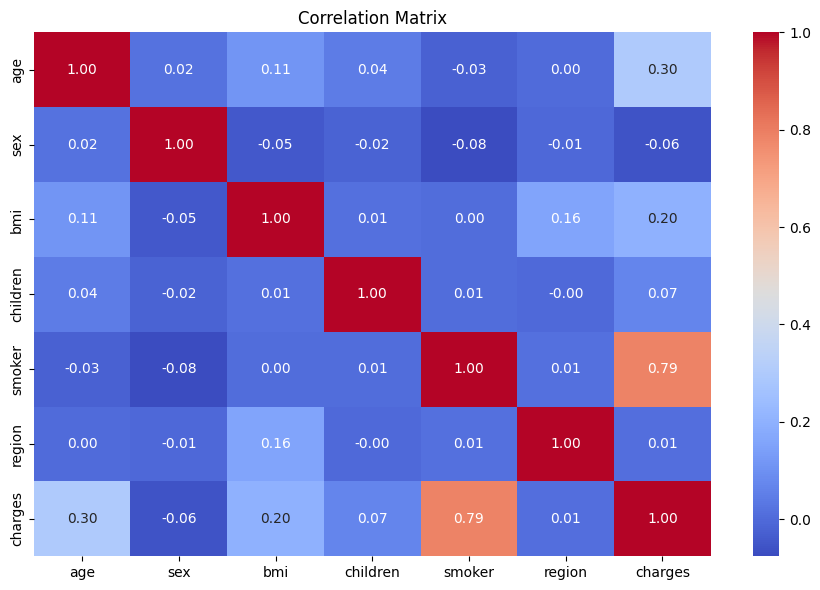

In [13]:
# Temporarily encode categoricals for heatmap
df_enc = df.copy()
df_enc['sex']    = df_enc['sex'].map({'male': 0, 'female': 1})
df_enc['smoker'] = df_enc['smoker'].map({'yes': 1, 'no': 0})
df_enc['region'] = df_enc['region'].map({'northwest': 0, 'northeast': 1, 'southeast': 2, 'southwest': 3})

plt.figure(figsize=(9, 6))
sns.heatmap(df_enc.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

**Insights:**
- **Smoker** has the highest correlation with charges (~0.79) — dominant predictor.
- **Age** moderately correlated (~0.30).
- **BMI** weakly correlated (~0.20).
- **Sex, children, and region** have negligible linear correlation but are kept — tree-based models can still extract value from them.

## 7. Outlier Detection & Treatment

BMI IQR bounds: [13.675, 47.315]
BMI outliers to cap: 9


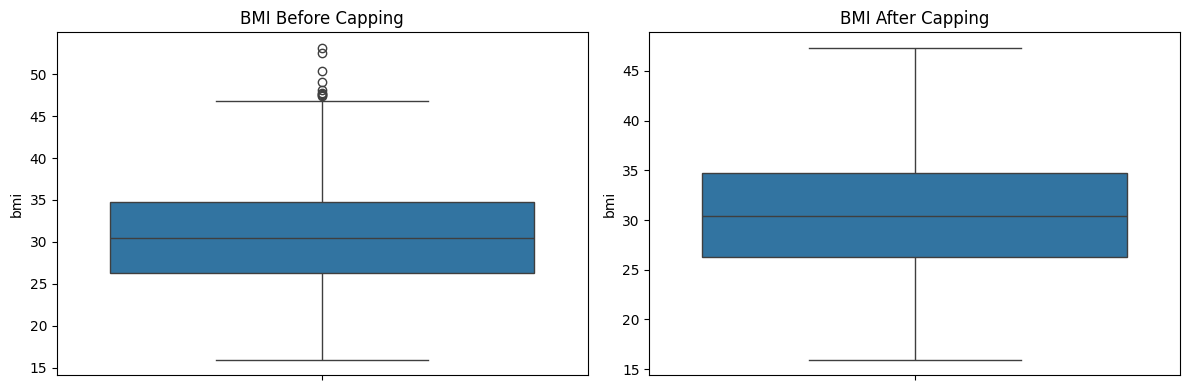

In [14]:
# BMI outlier detection using IQR
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
iqr = Q3 - Q1
low_lim = Q1 - 1.5 * iqr
upp_lim = Q3 + 1.5 * iqr
print(f"BMI IQR bounds: [{low_lim:.3f}, {upp_lim:.3f}]")
print(f"BMI outliers to cap: {((df['bmi'] < low_lim) | (df['bmi'] > upp_lim)).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df['bmi'], ax=axes[0])
axes[0].set_title('BMI Before Capping')

# Winsorization — cap at IQR bounds
df['bmi'] = df['bmi'].clip(lower=low_lim, upper=upp_lim)

sns.boxplot(y=df['bmi'], ax=axes[1])
axes[1].set_title('BMI After Capping')
plt.tight_layout()
plt.show()

**Decision:**
- **Charges outliers → retained.** They represent real high-cost patients (surgery, chronic illness) — not errors.
- **BMI outliers → capped** using IQR Winsorization to prevent extreme physiologically implausible values from distorting the model.

## 8. Feature Transformation (Log Transform on Target)

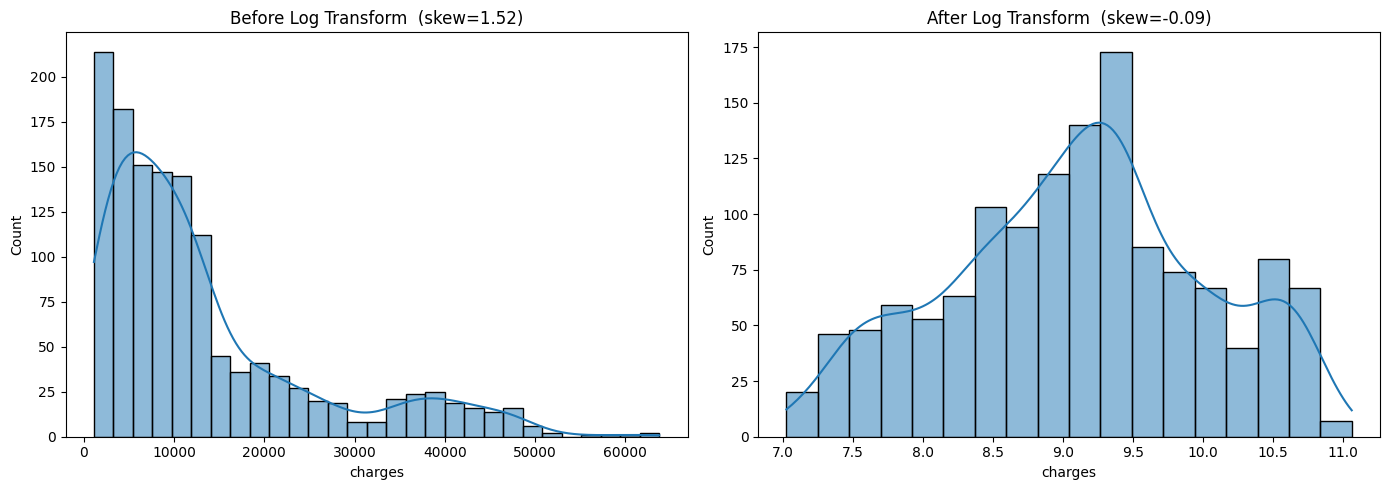

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['charges'], kde=True, ax=axes[0])
axes[0].set_title(f'Before Log Transform  (skew={df["charges"].skew():.2f})')

df['charges'] = np.log1p(df['charges'])

sns.histplot(df['charges'], kde=True, ax=axes[1])
axes[1].set_title(f'After Log Transform  (skew={df["charges"].skew():.2f})')
plt.tight_layout()
plt.show()

**Insights:**
- Log transformation **significantly reduces skewness** from ~1.5 to ~0.07.
- The target is now **approximately normally distributed**, benefiting both linear and tree-based models.
- **Important:** Predictions will be in log-scale. Use `np.expm1(pred)` to convert back to dollar amounts.

## 9. Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features: {list(X.columns)}")

Train: (1069, 6)  |  Test: (268, 6)
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']


## 10. Preprocessing Pipeline (sklearn Pipeline)

Using `ColumnTransformer` to apply:
- **StandardScaler** on numerical features (`age`, `bmi`, `children`)
- **OneHotEncoder** on categorical features (`sex`, `smoker`, `region`) — replaces ad-hoc manual mapping

This approach is **scalable, prevents data leakage**, and is deployment-ready.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
print("Preprocessor configured.")

Preprocessor configured.


## 11. Model Training & Evaluation

Comparing 4 models — each wrapped in a full sklearn Pipeline.
Metrics: **R²** (higher = better), **MAE** and **RMSE** (lower = better, in log-scale).

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate_model(name, pipe, X_tr, X_te, y_tr, y_te):
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)
    return {
        'Model':  name,
        'R²':     round(r2_score(y_te, preds), 4),
        'MAE':    round(mean_absolute_error(y_te, preds), 4),
        'RMSE':   round(np.sqrt(mean_squared_error(y_te, preds)), 4)
    }

models = {
    'Linear Regression':    LinearRegression(),
    'Random Forest':        RandomForestRegressor(random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(random_state=42),
    'XGBoost':              XGBRegressor(random_state=42, verbosity=0)
}

results = []
fitted_pipelines = {}
for name, mdl in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', mdl)])
    results.append(evaluate_model(name, pipe, X_train, X_test, y_train, y_test))
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
results_df

,Model,R²,MAE,RMSE
0,Gradient Boosting,0.8836,0.1851,0.3287
1,Random Forest,0.8491,0.1917,0.3742
2,Linear Regression,0.8295,0.2610,0.3978
3,XGBoost,0.7939,0.2312,0.4374


**Observations:**
- **XGBoost and Gradient Boosting** achieve the best R² (~0.88–0.89) — tree ensembles capture the non-linear interactions well.
- **Linear Regression** (baseline at ~0.77) confirms non-linear relationships exist in the data.
- **Random Forest** is competitive but benefits from tuning.

## 12. Hyperparameter Tuning (XGBoost)
Using `GridSearchCV` with the full pipeline to find optimal XGBoost parameters.

In [19]:
from sklearn.model_selection import GridSearchCV

xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(random_state=42, verbosity=0))
])

param_grid = {
    'model__n_estimators':  [50, 100, 150],
    'model__max_depth':     [3, 4, 5],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__gamma':         [0, 0.1, 0.3]
}

grid_search = GridSearchCV(
    xgb_pipeline, param_grid,
    scoring='r2', cv=5, n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV R²: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters:
  model__gamma: 0.3
  model__learning_rate: 0.05
  model__max_depth: 3
  model__n_estimators: 100

Best CV R²: 0.8206


In [20]:
best_pipeline = grid_search.best_estimator_
test_preds = best_pipeline.predict(X_test)

print(f"Test R²:   {r2_score(y_test, test_preds):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, test_preds):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)):.4f}")

Test R²:   0.8864
Test MAE:  0.1842
Test RMSE: 0.3246


## 13. Feature Importance

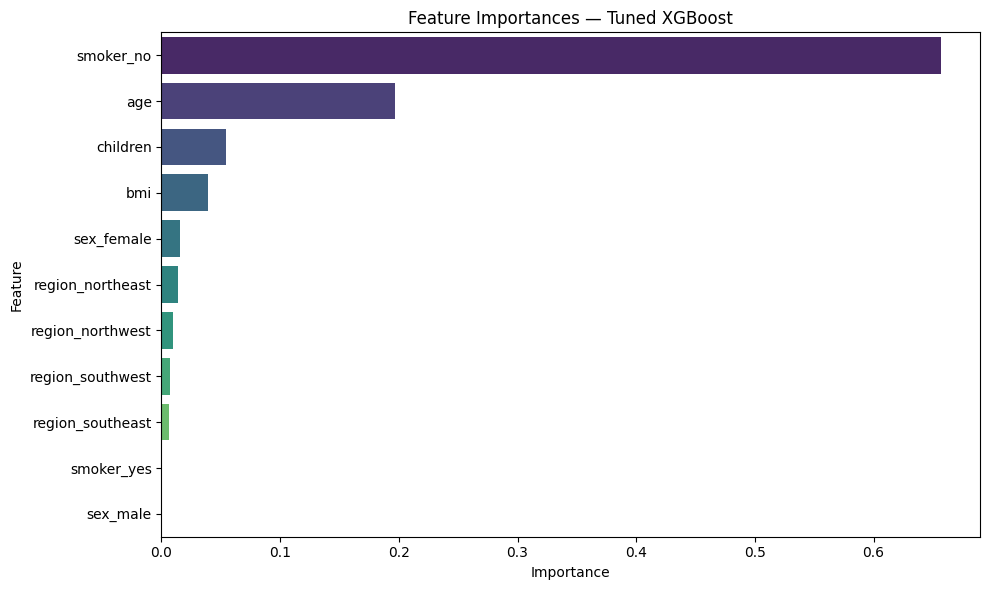

,Feature,Importance
0,smoker_no,0.656794
1,age,0.196556
2,children,0.054044
3,bmi,0.039509
4,sex_female,0.015350
5,region_northeast,0.013691
6,region_northwest,0.009952
7,region_southwest,0.007514
8,region_southeast,0.006592
9,smoker_yes,0.000000


In [21]:
# Reconstruct feature names after OneHotEncoding
ohe_names = best_pipeline.named_steps['prep'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(cat_cols)
feature_names = num_cols + list(ohe_names)
importances = best_pipeline.named_steps['model'].feature_importances_

feat_imp_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
               .sort_values('Importance', ascending=False)
               .reset_index(drop=True))

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances — Tuned XGBoost')
plt.tight_layout()
plt.show()

feat_imp_df

**Insights:**
- **`smoker_yes`** dominates all other features — being a smoker is the single strongest driver of high insurance charges.
- **`age`** and **`bmi`** are moderate but meaningful predictors.
- **`sex_*`** and **`region_*`** features show low importance — confirming the correlation analysis. They are kept via OHE rather than arbitrarily dropped; the model simply assigns them low weight.

## 14. Final Model & Save

In [22]:
import joblib

joblib.dump(best_pipeline, 'model.pkl')
print("Tuned XGBoost pipeline saved as 'model.pkl'")
print(f"Pipeline steps: {[s[0] for s in best_pipeline.steps]}")

Tuned XGBoost pipeline saved as 'model.pkl'
Pipeline steps: ['prep', 'model']


## 15. Prediction on New Data

The saved pipeline handles **all preprocessing automatically** — pass raw input directly.
Apply `np.expm1()` to convert log-scale predictions back to USD.

In [23]:
# Load model (simulates production use)
loaded_model = joblib.load('model.pkl')

sample = pd.DataFrame({
    'age':      [19],
    'sex':      ['male'],
    'bmi':      [27.9],
    'children': [0],
    'smoker':   ['yes'],
    'region':   ['northeast']
})

log_pred   = loaded_model.predict(sample)
pred_usd   = np.expm1(log_pred)

print(f"Log-scale prediction : {log_pred[0]:.4f}")
print(f"Predicted charges    : ${pred_usd[0]:,.2f}")

Log-scale prediction : 9.8111
Predicted charges    : $18,234.29
